---
title: Holiday Movie Analysis
author: Bryan Armpriest
date: 2025-03-02
categories: [python, pandas, music]
image: "christmas.jpg"
toc: true
---

In [1]:
#Let's load up some data from IMDB so that we can take a look at it!
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#We are given two dataframes, one with the bulk of the data:
holiday_movies = pd.read_csv("https://bcdanl.github.io/data/holiday_movies.csv")

#And another with genres!
holiday_movie_genres = pd.read_csv("https://bcdanl.github.io/data/holiday_movie_genres.csv")

In [ ]:
holiday_movies.info()
#holiday_movies

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           2265 non-null   object 
 1   title_type       2265 non-null   object 
 2   primary_title    2265 non-null   object 
 3   simple_title     2265 non-null   object 
 4   year             2265 non-null   int64  
 5   runtime_minutes  2076 non-null   float64
 6   average_rating   2265 non-null   float64
 7   num_votes        2265 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 141.7+ KB


,tconst,title_type,primary_title,simple_title,year,runtime_minutes,average_rating,num_votes
0,tt0020356,movie,Sailor's Holiday,sailors holiday,1929,58.0,5.4,55
1,tt0020823,movie,The Devil's Holiday,the devils holiday,1930,80.0,6.0,242
2,tt0020985,movie,Holiday,holiday,1930,91.0,6.3,638
3,tt0021268,movie,Holiday of St. Jorgen,holiday of st jorgen,1930,83.0,7.4,256
4,tt0021377,movie,Sin Takes a Holiday,sin takes a holiday,1930,81.0,6.1,740
...,...,...,...,...,...,...,...,...
2260,tt9747440,tvMovie,A Christmas Love Story,a christmas love story,2019,84.0,6.9,1652
2261,tt9747450,tvMovie,Holiday for Heroes,holiday for heroes,2019,81.0,7.0,1655
2262,tt9802890,tvMovie,Christmas Jars,christmas jars,2019,93.0,7.3,914
2263,tt9815084,tvMovie,A Very British Christmas,a very british christmas,2019,90.0,5.7,725


In [ ]:
holiday_movie_genres.info() #From looking at this data, there is a common variable with tconst
#holiday_movie_genres

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tconst  4531 non-null   object
 1   genres  4499 non-null   object
dtypes: object(2)
memory usage: 70.9+ KB


,tconst,genres
0,tt0020356,Comedy
1,tt0020823,Drama
2,tt0020823,Romance
3,tt0020985,Comedy
4,tt0020985,Drama
...,...,...
4526,tt9815084,Family
4527,tt9815084,Romance
4528,tt9892854,Comedy
4529,tt9892854,Drama


With this in mind, I am going to join these two tables using merge() with the proper 'how' function! (joining!)


In [2]:
hm_merged = pd.merge(holiday_movies, holiday_movie_genres, on='tconst', how='left')
hm_merged = hm_merged.drop_duplicates(['simple_title'], keep = 'first')

Now that these two tables are joined, we can ask a few questions about the dataframe!

Let's start with finding the proportions of the genres that we have just imported. (counting and indexing!)

In [ ]:
genre_count = pd.DataFrame(hm_merged['genres'].value_counts().reset_index())
genre_count #the top 3 genres of holiday movies in terms of frequency are comedy, drama and romance

,genres,count
0,Comedy,827
1,Drama,391
2,Animation,191
3,Family,157
4,Romance,126
5,Adventure,98
6,Documentary,89
7,Horror,31
8,Action,29
9,Music,26


Let's also say that I was interested in a specific movie, and didn't feel like using a filtering method to find it!

In [ ]:
name_to_index = hm_merged.set_index(keys = ['simple_title'])

name_to_index.loc['christmas wedding baby'] #interesting! This is how I knew that I need to drop duplicates for accurate results!

,christmas wedding baby
tconst,tt3783740
title_type,movie
primary_title,Christmas Wedding Baby
year,2014
runtime_minutes,112.0
average_rating,6.0
num_votes,75
genres,Comedy


Now, one could be curious as to how the top 3 categories relate to one another in terms of ratings. I will use filtering methods and calculate the mean ratings of each.

In [ ]:
comedy = hm_merged.query("genres == 'Comedy'")
drama = hm_merged.query("genres == 'Drama'")
romance = hm_merged.query("genres == 'Romance'")

In [ ]:
float(hm_merged['average_rating'].mean()) #returns 6.056

6.075108538350217

In [ ]:
float(comedy['average_rating'].mean()) #returns 5.914

5.878355501813784

In [ ]:
float(drama['average_rating'].mean()) #returns 6.068

6.174680306905372

In [ ]:
float(romance['average_rating'].mean()) #returns 6.035

6.020634920634919

The average rating for all holiday movies in the list happens to be around 6.1. Comedies tended to rate lower than this, but not by much. This seems to be quite a complex dynamic, and next, I would like to explore the highest rated comedy films and the lowest ones.

In [ ]:
descending_comedy = comedy.sort_values(['average_rating'], ascending = False)
descending_comedy[['simple_title', 'average_rating']]

,simple_title,average_rating
3062,christmas bone us,9.8
3214,cheap vs expensive xmas day,9.5
2838,aunty donna always room for christmas pud,9.3
1089,santa claus versus the christmas vixens,9.1
4483,holiday twist,9.0
...,...,...
4048,how the wrong brothers saved christmas,2.1
4222,a feminist christmas carol,1.8
4341,a raunchy christmas story,1.7
1874,a christmas call,1.5


In [ ]:
ascending_comedy = comedy.sort_values(['average_rating'], ascending = True)
ascending_comedy[['simple_title', 'average_rating']]

,simple_title,average_rating
3560,kirk camerons saving christmas,1.3
1874,a christmas call,1.5
4341,a raunchy christmas story,1.7
4222,a feminist christmas carol,1.8
4048,how the wrong brothers saved christmas,2.1
...,...,...
4483,holiday twist,9.0
1089,santa claus versus the christmas vixens,9.1
2838,aunty donna always room for christmas pud,9.3
3214,cheap vs expensive xmas day,9.5


Not surprisingly, there is quite a range of ratings for holiday movies that could also be considered comedies. They seem to range from an abysmal 1.3 to a fabulous 9.8. With all things considered, I'm surprised that I've never even heard of most of these highly acclaimed films/shows.

# Approach 2: Data Visualization

1. Use pandas to select the five genres with the highest film counts.


2. Use numpy to add a new variable, log of num_votes.


3. Use seaborn to plot the relationship between log of num_votes and average_rating, grouping by genre and coloring or faceting by title_type.

In [27]:
genre_count = hm_merged.groupby('genres').agg(film_count = ('primary_title', 'count')).reset_index()
top_5 = genre_count.nlargest(5, 'film_count', keep = 'all')
top_5_genre = top_5['genres'].to_list()
top_5_genre #Comedy, Drama, Animation, Family, Romance

movies_top_5_genre = hm_merged[hm_merged['genres'].isin(top_5_genre)]
movies_top_5_genre #Here is the selected dataframe with the highest film counts!

,tconst,title_type,primary_title,simple_title,year,runtime_minutes,average_rating,num_votes,genres
0,tt0020356,movie,Sailor's Holiday,sailors holiday,1929,58.0,5.4,55,Comedy
1,tt0020823,movie,The Devil's Holiday,the devils holiday,1930,80.0,6.0,242,Drama
3,tt0020985,movie,Holiday,holiday,1930,91.0,6.3,638,Comedy
5,tt0021268,movie,Holiday of St. Jorgen,holiday of st jorgen,1930,83.0,7.4,256,Comedy
6,tt0021377,movie,Sin Takes a Holiday,sin takes a holiday,1930,81.0,6.1,740,Comedy
...,...,...,...,...,...,...,...,...,...
4520,tt9747440,tvMovie,A Christmas Love Story,a christmas love story,2019,84.0,6.9,1652,Drama
4523,tt9747450,tvMovie,Holiday for Heroes,holiday for heroes,2019,81.0,7.0,1655,Romance
4524,tt9802890,tvMovie,Christmas Jars,christmas jars,2019,93.0,7.3,914,Drama
4525,tt9815084,tvMovie,A Very British Christmas,a very british christmas,2019,90.0,5.7,725,Comedy


In [28]:
#Addition of log(num_votes) variable
movies_top_5_genre['log_num_votes'] = np.log(movies_top_5_genre['num_votes'])
movies_top_5_genre

<ipython-input-28-b3667304645d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_top_5_genre['log_num_votes'] = np.log(movies_top_5_genre['num_votes'])


,tconst,title_type,primary_title,simple_title,year,runtime_minutes,average_rating,num_votes,genres,log_num_votes
0,tt0020356,movie,Sailor's Holiday,sailors holiday,1929,58.0,5.4,55,Comedy,4.007333
1,tt0020823,movie,The Devil's Holiday,the devils holiday,1930,80.0,6.0,242,Drama,5.488938
3,tt0020985,movie,Holiday,holiday,1930,91.0,6.3,638,Comedy,6.458338
5,tt0021268,movie,Holiday of St. Jorgen,holiday of st jorgen,1930,83.0,7.4,256,Comedy,5.545177
6,tt0021377,movie,Sin Takes a Holiday,sin takes a holiday,1930,81.0,6.1,740,Comedy,6.606650
...,...,...,...,...,...,...,...,...,...,...
4520,tt9747440,tvMovie,A Christmas Love Story,a christmas love story,2019,84.0,6.9,1652,Drama,7.409742
4523,tt9747450,tvMovie,Holiday for Heroes,holiday for heroes,2019,81.0,7.0,1655,Romance,7.411556
4524,tt9802890,tvMovie,Christmas Jars,christmas jars,2019,93.0,7.3,914,Drama,6.817831
4525,tt9815084,tvMovie,A Very British Christmas,a very british christmas,2019,90.0,5.7,725,Comedy,6.586172


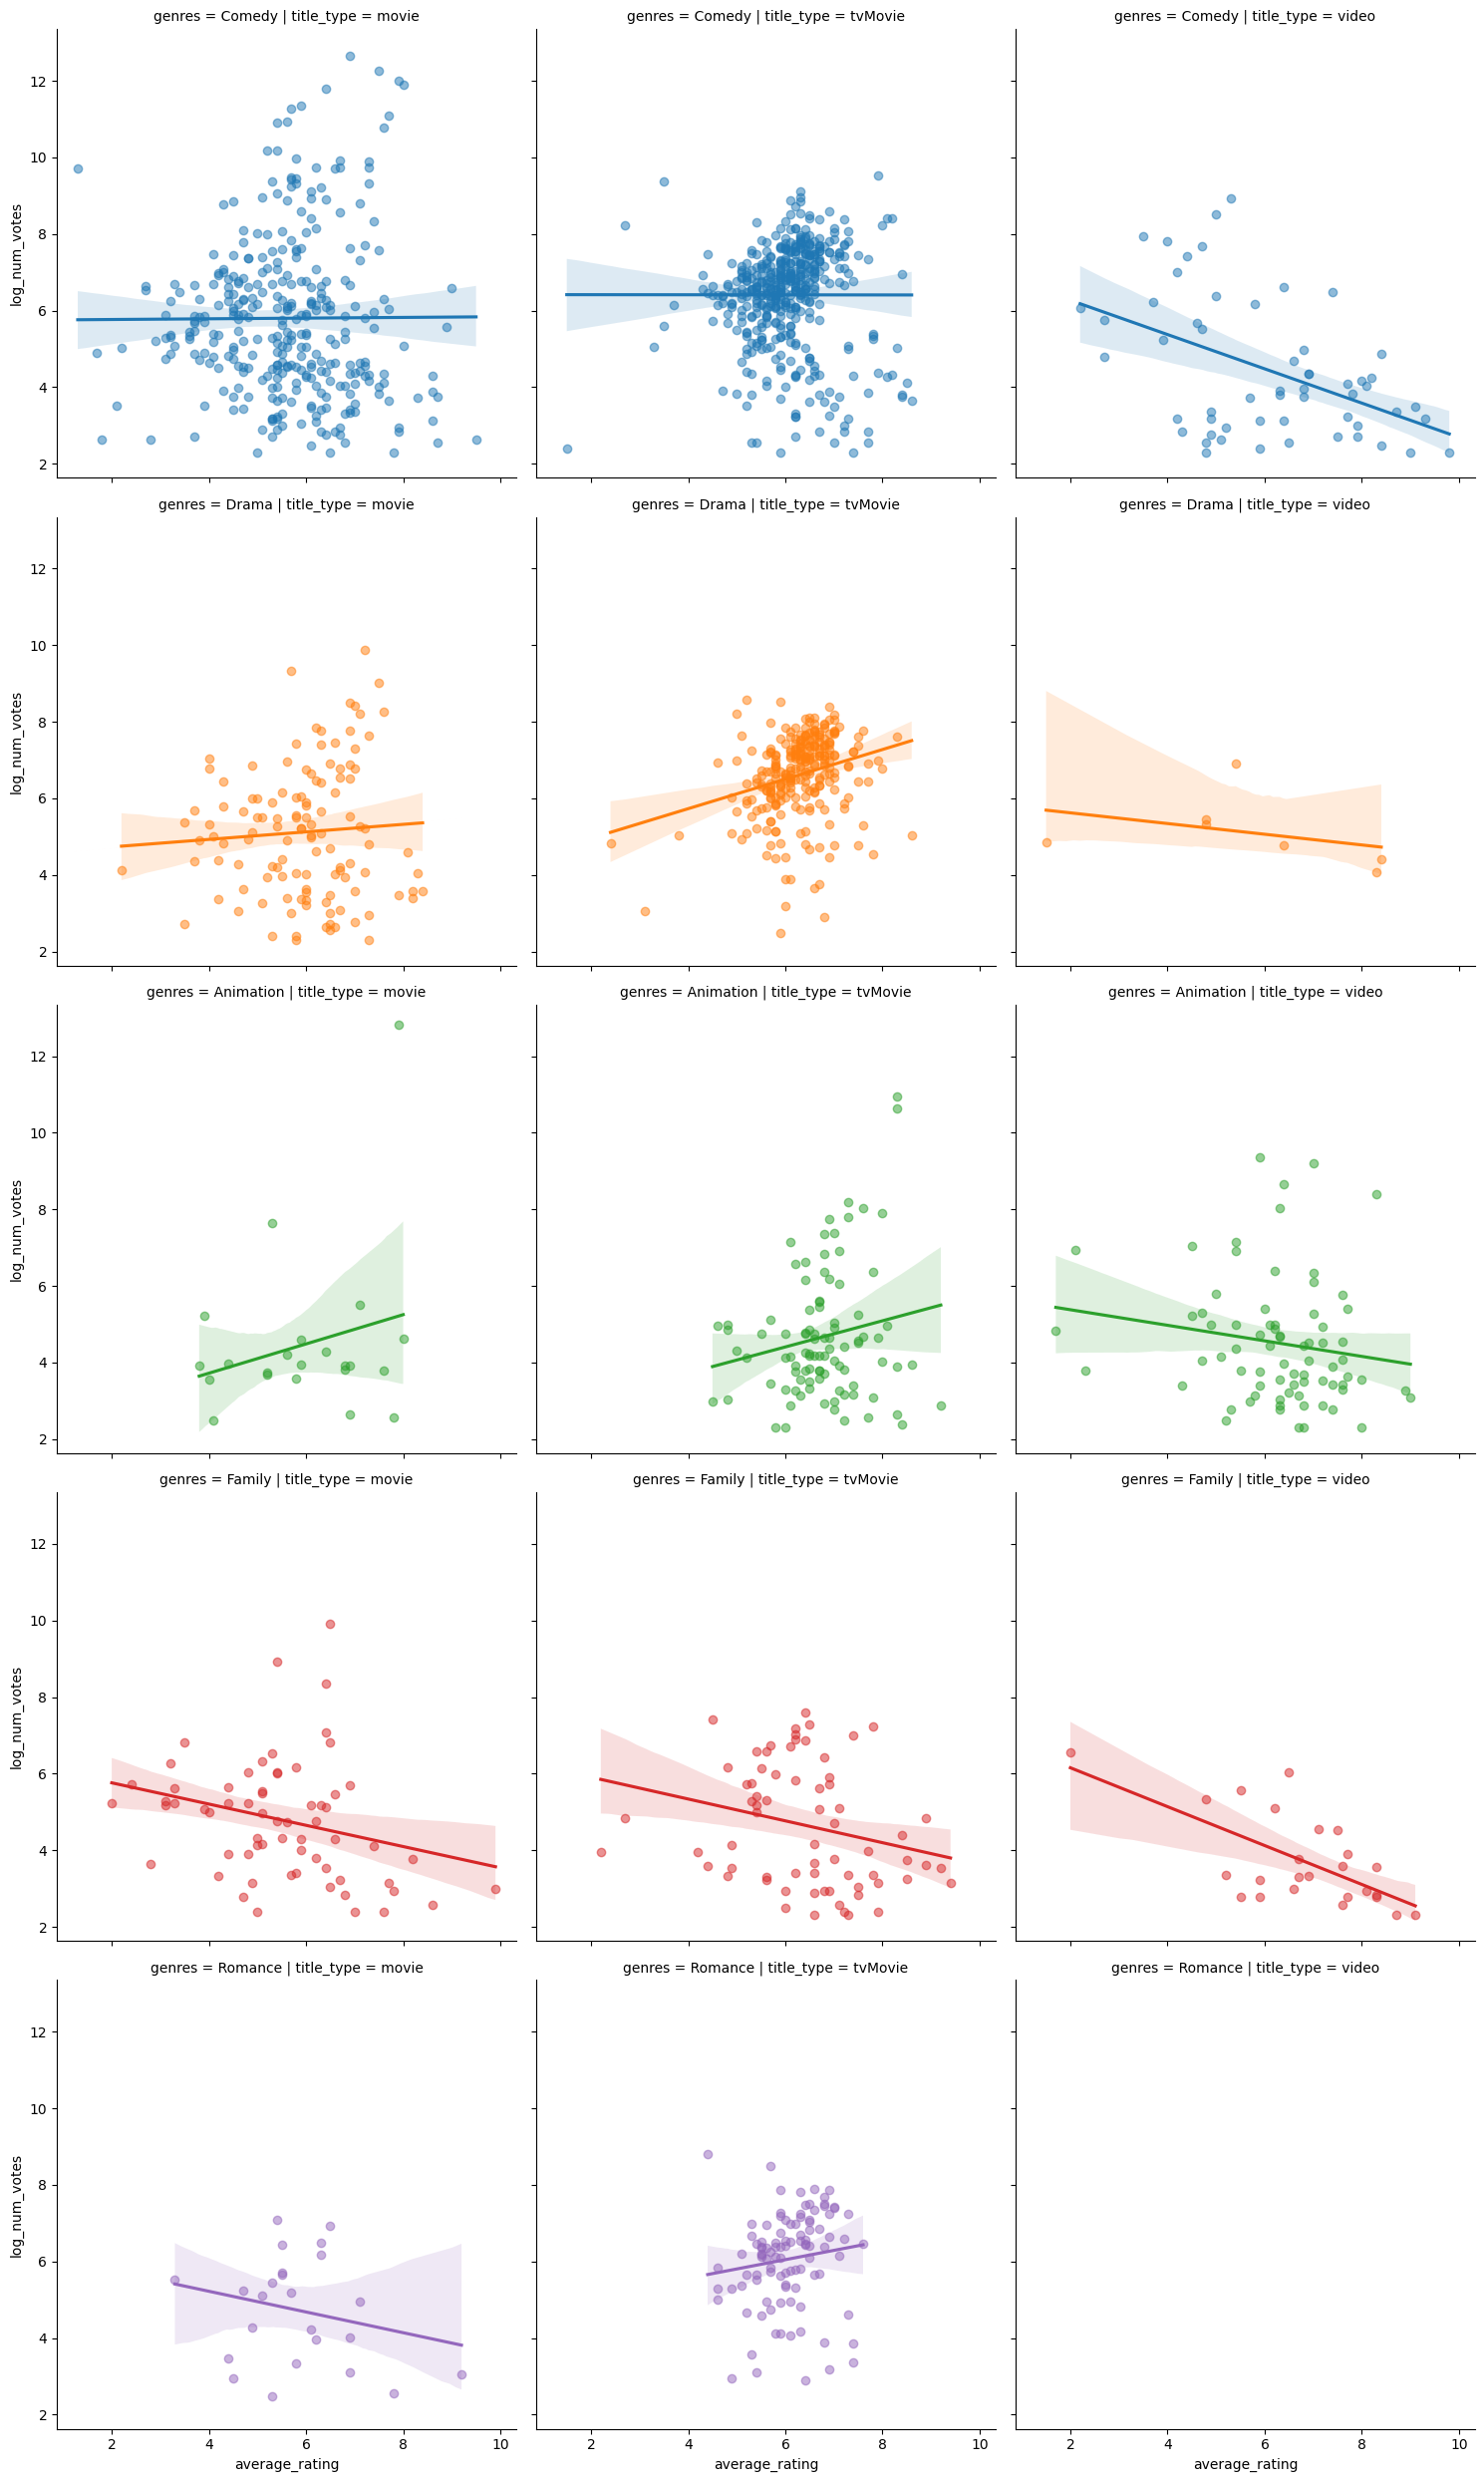

In [31]:
#Use of seaborn to plot the relationship between log_num_votes and average rating
sns.lmplot(data = movies_top_5_genre,
           x = 'average_rating', y = 'log_num_votes',
           hue = 'genres',
           scatter_kws = {'alpha' : 0.5},
           col = 'title_type',
           row = 'genres')

There is certainly a lot of information to unpack from these graphs, but I will try my best to summarize it two or three sentences:

 In a few instances, there seems to be more negative ratings corresponding to higher number of votes, which could point to a classic explanation in rating systems, where customers that are dissatisfied are more likely to complain, and therefore leave a bad review. The only clear graph with a positive relationship between the average rating and the number of ratings happens to be the tvMovie Holiday Dramas. Otherwise, there is often a negative (or no) correlation between the average rating of a movie/film/video and the logarithmic value of the number of votes.

### As always, thank you for reading!